# Análisis de Clustering de Campaña de Marketing

## 1. Cargar y explorar los datos

In [1]:
# Importar las librerías necesarias
import pandas as pd  # Para la manipulación de datos
import numpy as np  # Para operaciones numéricas
from sklearn.preprocessing import StandardScaler, OneHotEncoder  # Para el preprocesamiento de datos
from sklearn.compose import ColumnTransformer  # Para aplicar diferentes transformaciones a diferentes columnas
from sklearn.pipeline import Pipeline  # Para encadenar pasos de preprocesamiento y modelado
from sklearn.impute import SimpleImputer  # Para manejar valores faltantes

# Cargar el conjunto de datos
file_path = '../data/raw/marketing_campaign.csv'
df = pd.read_csv(file_path, sep='	')

# Mostrar las primeras filas del dataframe
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [2]:
# Obtener un resumen de la información del dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [3]:
# Verificar la cantidad de valores nulos en cada columna
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

## 2. Limpieza y Preprocesamiento de Datos

In [4]:
# Imputar valores faltantes en la columna 'Income' con la media
df['Income'].fillna(df['Income'].mean(), inplace=True)

# Convertir la columna 'Dt_Customer' a formato de fecha y calcular la antiguedad del cliente en días
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)
df['Customer_Lifetime'] = (pd.to_datetime('today') - df['Dt_Customer']).dt.days
df.drop('Dt_Customer', axis=1, inplace=True) # Eliminar la columna original de fecha

# Filtrar registros con 'Year_Birth' mayor a 1920 para eliminar valores atípicos
df = df[df['Year_Birth'] > 1920]
# Calcular la edad del cliente y eliminar la columna 'Year_Birth'
df['Age'] = pd.to_datetime('today').year - df['Year_Birth']
df.drop('Year_Birth', axis=1, inplace=True)

# Eliminar columnas irrelevantes para el análisis de clustering
df.drop(['ID', 'Z_CostContact', 'Z_Revenue'], axis=1, inplace=True)

# Identificar las características categóricas y numéricas
categorical_features = ['Education', 'Marital_Status']
numerical_features = df.select_dtypes(include=np.number).columns.tolist()

# Crear un transformador de columnas para aplicar el preprocesamiento adecuado a cada tipo de característica
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),  # Estandarizar características numéricas
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features) # Codificar características categóricas
    ])

# Crear un pipeline que encadena el preprocesador
pipeline = Pipeline(steps=[('preprocessor', preprocessor)])

# Aplicar el pipeline de preprocesamiento a los datos
df_processed = pipeline.fit_transform(df)

# Imprimir las dimensiones de los datos procesados para verificar
print('Dimensiones de los datos procesados:', df_processed.shape)

Dimensiones de los datos procesados: (2237, 37)


/tmp/ipykernel_21756/1654103935.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Income'].fillna(df['Income'].mean(), inplace=True)


## 3. K-Means Clustering

### 3.1. Encontrar el número óptimo de clusters (Método del Codo)

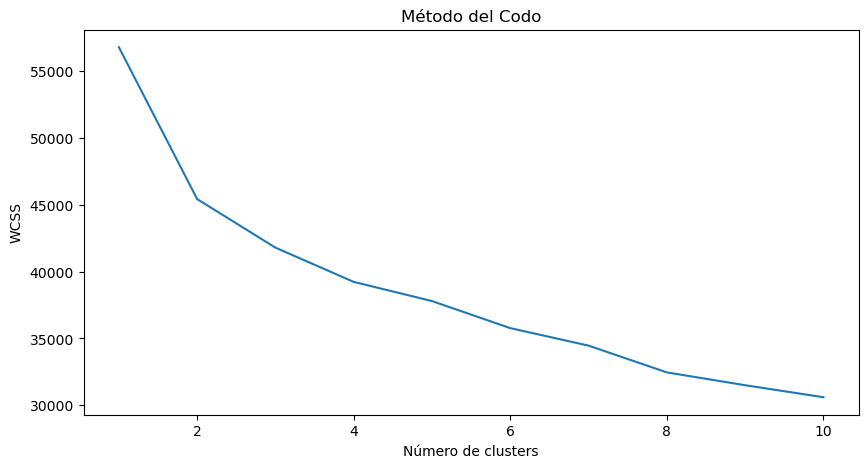

In [5]:
# Importar las librerías necesarias para el clustering y la visualización
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Calcular la inercia (WCSS) para diferentes números de clusters
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(df_processed)
    wcss.append(kmeans.inertia_)

# Graficar el método del codo para encontrar el número óptimo de clusters
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss)
plt.title('Método del Codo')
plt.xlabel('Número de clusters')
plt.ylabel('WCSS')
plt.savefig('../reports/elbow_method.png') # Guardar el gráfico
plt.show()

### 3.2. Aplicar K-Means y Analizar los Clusters

In [6]:
# Aplicar K-Means con el número óptimo de clusters (k=3)
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, n_init=10, random_state=0)
clusters_kmeans = kmeans.fit_predict(df_processed)

# Añadir las etiquetas de los clusters al dataframe original
df['Cluster_KMeans'] = clusters_kmeans

# Analizar las características de cada cluster
cluster_analysis_kmeans = df.groupby('Cluster_KMeans').mean(numeric_only=True)
cluster_analysis_kmeans

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Customer_Lifetime,Age
Cluster_KMeans,,,,,,,,,,,,,,,,,,,,,
0,58339.821892,0.207813,0.915625,48.315625,469.396875,25.353125,142.687500,33.901562,26.325000,62.815625,...,5.670312,0.064062,0.134375,0.014063,0.031250,0.014063,0.009375,0.110937,4540.073438,60.604687
1,35364.252627,0.795821,0.450142,49.377018,43.897436,5.058879,24.188034,7.143400,5.125356,15.526116,...,6.438746,0.073124,0.009497,0.000000,0.000950,0.001899,0.011396,0.091168,4450.226971,53.339981
2,77715.891554,0.042279,0.134191,49.505515,612.867647,68.408088,471.696691,100.588235,70.419118,76.851103,...,2.738971,0.082721,0.130515,0.281250,0.226103,0.034926,0.003676,0.306985,4482.542279,56.136029


### 3.3. Visualizar los Clusters de K-Means

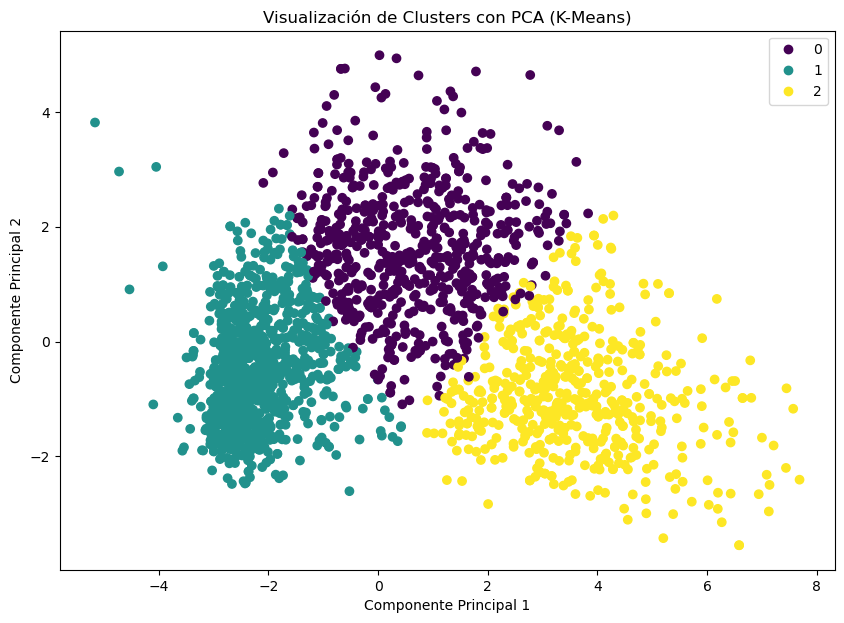

In [7]:
# Reducir la dimensionalidad usando PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_processed)

# Crear un scatter plot para visualizar los clusters
plt.figure(figsize=(10, 7))
scatter = plt.scatter(df_pca[:, 0], df_pca[:, 1], c=clusters_kmeans, cmap='viridis')
plt.title('Visualización de Clusters con PCA (K-Means)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(handles=scatter.legend_elements()[0], labels=range(3))
plt.savefig('../reports/clusters_pca_kmeans.png') # Guardar el gráfico
plt.show()

## 4. Clustering Jerárquico

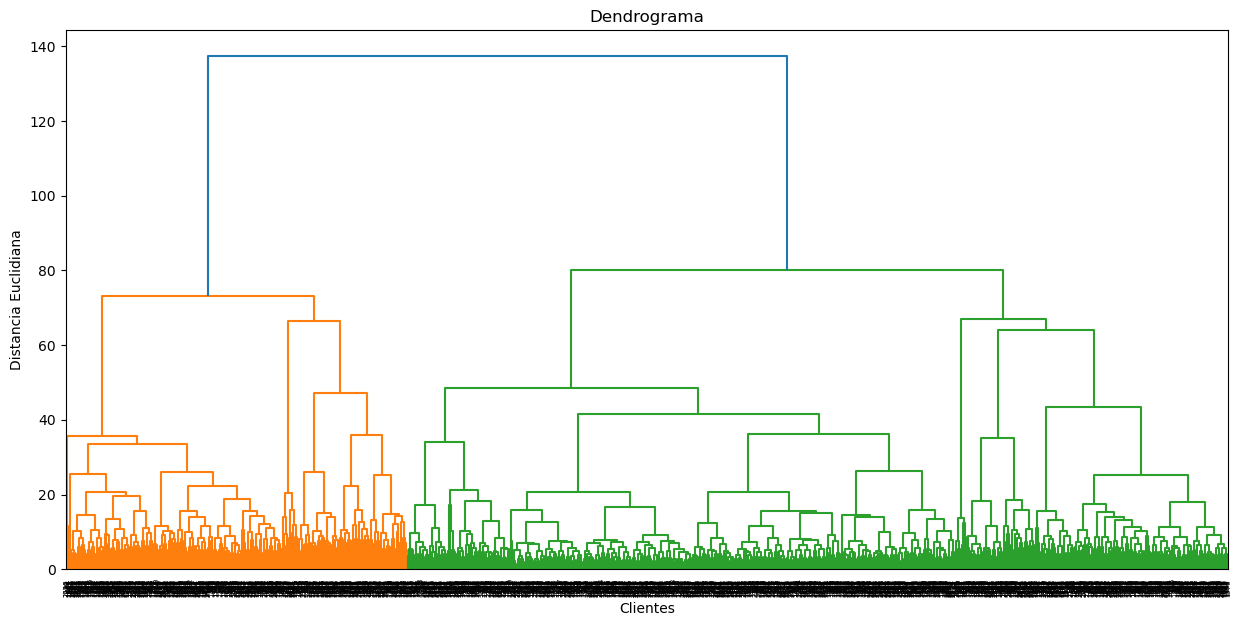

In [8]:
# Importar la librería necesaria para el dendrograma
from scipy.cluster.hierarchy import dendrogram, linkage

# Generar el dendrograma para visualizar el clustering jerárquico
plt.figure(figsize=(15, 7))
dendrogram(linkage(df_processed, method='ward'))
plt.title('Dendrograma')
plt.xlabel('Clientes')
plt.ylabel('Distancia Euclidiana')
plt.savefig('../reports/dendrogram.png') # Guardar el gráfico
plt.show()

In [9]:
# Aplicar Clustering Jerárquico con 3 clusters
from sklearn.cluster import AgglomerativeClustering

hierarchical = AgglomerativeClustering(n_clusters=3, linkage='ward')
clusters_hierarchical = hierarchical.fit_predict(df_processed)

# Añadir las etiquetas de los clusters al dataframe
df['Cluster_Hierarchical'] = clusters_hierarchical

# Analizar los clusters
cluster_analysis_hierarchical = df.groupby('Cluster_Hierarchical').mean(numeric_only=True)
cluster_analysis_hierarchical

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Customer_Lifetime,Age,Cluster_KMeans
Cluster_Hierarchical,,,,,,,,,,,,,,,,,,,,,
0,74599.394990,0.054795,0.281583,48.582953,573.066971,63.426180,410.397260,90.503805,66.493151,74.438356,...,0.042618,0.136986,0.237443,0.217656,0.045662,0.000000,0.261796,4483.369863,56.741248,1.578387
1,54823.637158,0.243810,0.824762,49.860952,447.165714,19.592381,130.944762,26.291429,18.508571,56.588571,...,0.255238,0.146667,0.011429,0.001905,0.000000,0.038095,0.158095,4525.971429,59.388571,0.304762
2,37023.011390,0.786730,0.488152,49.053081,65.185782,6.454976,33.190521,10.118483,6.777251,18.713744,...,0.000948,0.000000,0.000000,0.000000,0.000000,0.000000,0.074882,4463.061611,54.060664,0.894787


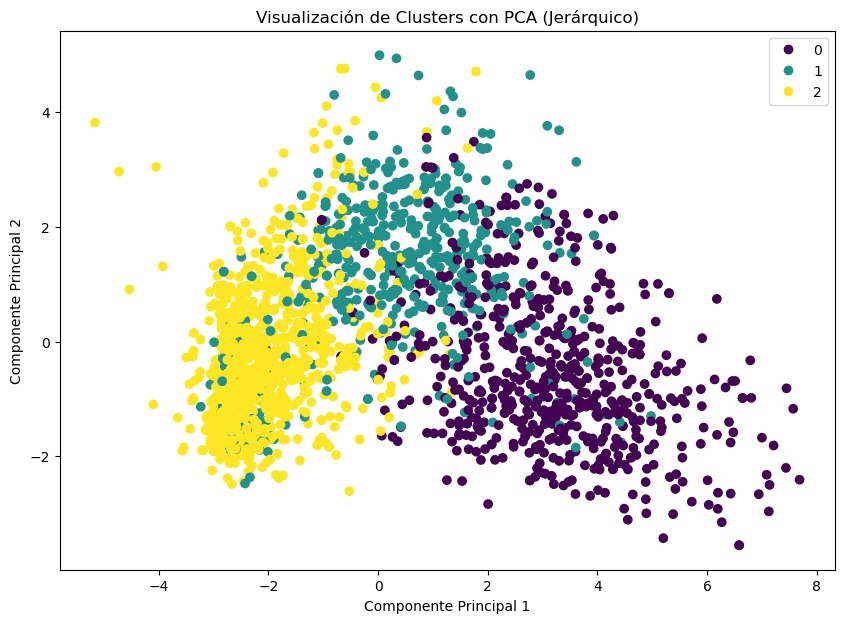

In [10]:
# Visualizar los clusters jerárquicos con PCA
plt.figure(figsize=(10, 7))
scatter = plt.scatter(df_pca[:, 0], df_pca[:, 1], c=clusters_hierarchical, cmap='viridis')
plt.title('Visualización de Clusters con PCA (Jerárquico)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(handles=scatter.legend_elements()[0], labels=range(3))
plt.savefig('../reports/clusters_pca_hierarchical.png') # Guardar el gráfico
plt.show()

## 5. DBSCAN Clustering

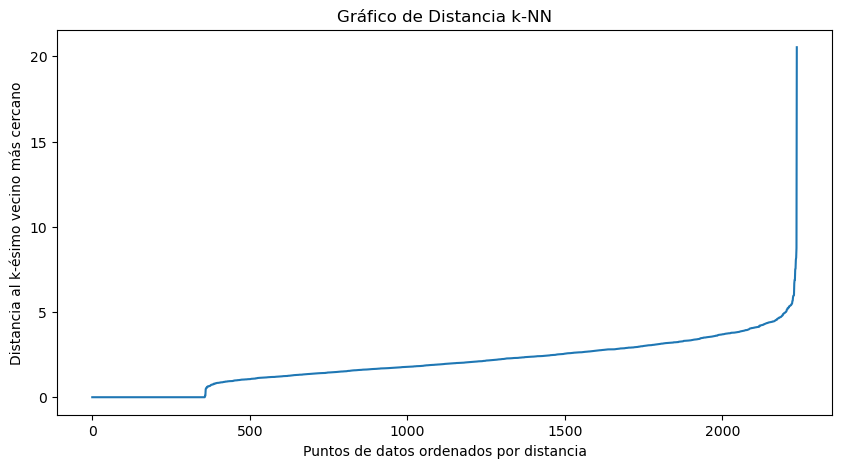

In [11]:
# Encontrar el valor óptimo para epsilon (eps) usando NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

# Calcular la distancia a los k vecinos más cercanos
k = 2 * df_processed.shape[1] - 1 # Regla general para min_samples
neigh = NearestNeighbors(n_neighbors=k)
nbrs = neigh.fit(df_processed)
distances, indices = nbrs.kneighbors(df_processed)

# Graficar la distancia al k-ésimo vecino más cercano
distances = np.sort(distances, axis=0)
distances = distances[:,1]
plt.figure(figsize=(10, 5))
plt.plot(distances)
plt.title('Gráfico de Distancia k-NN')
plt.xlabel('Puntos de datos ordenados por distancia')
plt.ylabel('Distancia al k-ésimo vecino más cercano')
plt.savefig('../reports/dbscan_knn_distance.png') # Guardar el gráfico
plt.show()

In [12]:
# Aplicar DBSCAN
# Basado en el gráfico anterior, un buen valor para eps podría estar alrededor de 4.5
dbscan = DBSCAN(eps=4.5, min_samples=5)
clusters_dbscan = dbscan.fit_predict(df_processed)

# Añadir las etiquetas de los clusters al dataframe
df['Cluster_DBSCAN'] = clusters_dbscan

# Analizar los clusters (excluyendo el ruido -1)
cluster_analysis_dbscan = df[df['Cluster_DBSCAN'] != -1].groupby('Cluster_DBSCAN').mean(numeric_only=True)
print('Número de clusters encontrados:', len(np.unique(clusters_dbscan)) - 1)
print('Número de puntos de ruido:', list(clusters_dbscan).count(-1))
cluster_analysis_dbscan

Número de clusters encontrados: 7
Número de puntos de ruido: 151


,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Customer_Lifetime,Age,Cluster_KMeans,Cluster_Hierarchical
Cluster_DBSCAN,,,,,,,,,,,,,,,,,,,,,
0,49190.035151,0.478589,0.530982,49.257431,254.843829,23.764232,140.353652,33.171285,24.002015,40.314358,...,0.039798,0.025693,0.0,0.0,0.0,0.111839,4484.229723,56.047355,0.889169,1.297229
1,79539.789474,0.052632,0.315789,50.421053,1035.631579,25.842105,307.894737,31.473684,29.631579,37.789474,...,1.000000,1.000000,0.0,0.0,0.0,0.421053,4422.894737,58.315789,1.578947,0.000000
2,38577.600000,0.666667,0.600000,48.800000,113.600000,14.200000,52.066667,18.600000,9.800000,15.733333,...,0.000000,0.000000,0.0,0.0,1.0,0.066667,4542.466667,58.133333,0.733333,1.000000
3,55977.000000,0.000000,0.833333,28.500000,548.333333,2.500000,50.333333,0.500000,4.000000,21.500000,...,1.000000,0.000000,1.0,0.0,0.0,0.500000,4284.666667,56.666667,0.166667,0.000000
4,74471.441860,0.023256,0.209302,54.604651,596.372093,46.139535,439.883721,102.395349,55.930233,77.465116,...,0.000000,0.000000,1.0,0.0,0.0,0.232558,4435.093023,61.162791,1.674419,0.000000
5,81611.400000,0.000000,0.000000,24.800000,912.000000,38.600000,534.800000,83.600000,68.100000,49.900000,...,0.000000,1.000000,1.0,0.0,0.0,0.900000,4458.800000,54.000000,2.000000,0.000000
6,86699.250000,0.000000,0.000000,48.750000,927.000000,87.625000,770.875000,82.375000,82.500000,56.750000,...,1.000000,1.000000,1.0,0.0,0.0,0.875000,4325.750000,47.750000,2.000000,0.000000


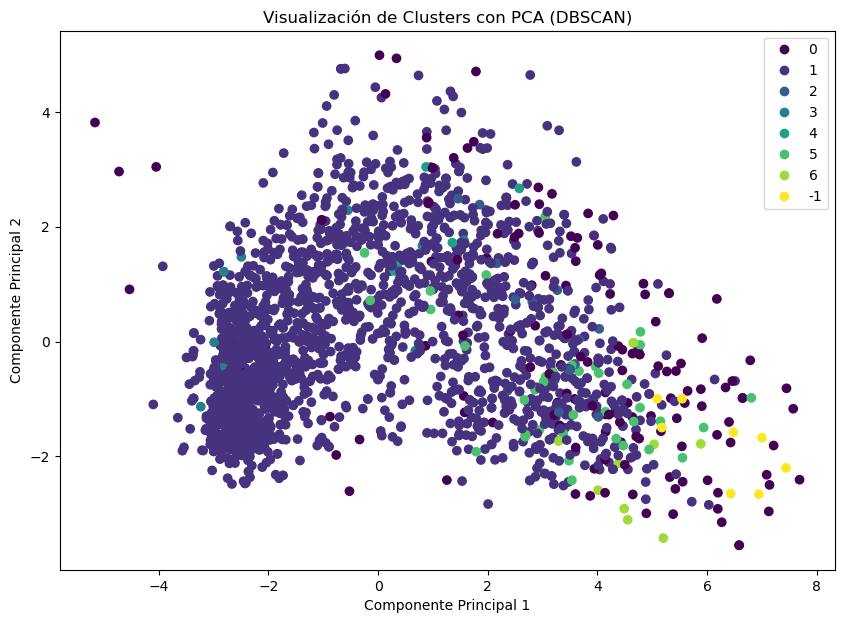

In [13]:
# Visualizar los clusters de DBSCAN con PCA
plt.figure(figsize=(10, 7))
scatter = plt.scatter(df_pca[:, 0], df_pca[:, 1], c=clusters_dbscan, cmap='viridis')
plt.title('Visualización de Clusters con PCA (DBSCAN)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(handles=scatter.legend_elements()[0], labels=set(clusters_dbscan))
plt.savefig('../reports/clusters_pca_dbscan.png') # Guardar el gráfico
plt.show()

## 6. Comparación de Modelos

In [14]:
# Calcular el Coeficiente de Silueta para cada modelo
from sklearn.metrics import silhouette_score

silhouette_kmeans = silhouette_score(df_processed, clusters_kmeans)
silhouette_hierarchical = silhouette_score(df_processed, clusters_hierarchical)
silhouette_dbscan = silhouette_score(df_processed, clusters_dbscan)

print(f'Coeficiente de Silueta para K-Means: {silhouette_kmeans:.2f}')
print(f'Coeficiente de Silueta para Clustering Jerárquico: {silhouette_hierarchical:.2f}')
print(f'Coeficiente de Silueta para DBSCAN: {silhouette_dbscan:.2f}')

Coeficiente de Silueta para K-Means: 0.16
Coeficiente de Silueta para Clustering Jerárquico: 0.15
Coeficiente de Silueta para DBSCAN: 0.19
